# 🤖 Home Credit Default Risk — LightGBM Modeling

This notebook trains a LightGBM classifier on the engineered features from `feature_engineering.ipynb`.

## Pipeline
1. Load engineered features
2. Clean column names (fix special characters)
3. Stratified K-Fold cross-validation
4. Feature importance analysis
5. Threshold optimization
6. Out-of-fold predictions & evaluation
7. Generate submission file

## 0. Setup

In [1]:
%matplotlib inline

import os
import re
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

RANDOM_STATE = 42
N_FOLDS      = 5
DATA_PATH    = os.path.expanduser('~/.cache/kagglehub/competitions/home-credit-default-risk')

print('LightGBM version:', lgb.__version__)
print('Data path       :', DATA_PATH)

LightGBM version: 4.6.0
Data path       : /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk


---
## 1. Load Engineered Features

In [2]:
print('Loading features...')
train = pd.read_csv(os.path.join(DATA_PATH, 'train_features.csv'))
test  = pd.read_csv(os.path.join(DATA_PATH, 'test_features.csv'))

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

TARGET = 'TARGET'
y      = train[TARGET]
X      = train.drop(columns=[TARGET])

X_test = test[[c for c in X.columns if c in test.columns]]
missing_test_cols = set(X.columns) - set(X_test.columns)
if missing_test_cols:
    print(f'Filling {len(missing_test_cols)} missing test columns with 0')
    for col in missing_test_cols:
        X_test[col] = 0
X_test = X_test[X.columns]

print(f'\nFeature matrix X     : {X.shape}')
print(f'Feature matrix X_test: {X_test.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True).rename('proportion').round(4))

Loading features...
Train shape : (307511, 274)
Test  shape : (48744, 273)

Feature matrix X     : (307511, 273)
Feature matrix X_test: (48744, 273)

Target distribution:
TARGET
0   0.9193
1   0.0807
Name: proportion, dtype: float64


---
## 2. Clean Column Names

LightGBM rejects feature names with special JSON characters (`[`, `]`, `{`, `}`, `,`, `"`, etc.).
These can appear in one-hot encoded column names produced by `pd.get_dummies()`.

In [3]:
def clean_column_names(df):
    """Replace any character that is not alphanumeric or underscore with '_'."""
    df = df.copy()
    new_cols = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    # Deduplicate names that became identical after cleaning
    seen = {}
    final_cols = []
    for col in new_cols:
        if col in seen:
            seen[col] += 1
            final_cols.append(f'{col}_{seen[col]}')
        else:
            seen[col] = 0
            final_cols.append(col)
    df.columns = final_cols
    return df


X      = clean_column_names(X)
X_test = clean_column_names(X_test)

# Verify
bad_cols = [c for c in X.columns if re.search(r'[^A-Za-z0-9_]', c)]
print(f'X shape          : {X.shape}')
print(f'X_test shape     : {X_test.shape}')
print(f'Bad column names : {len(bad_cols)} (should be 0)')
if bad_cols:
    print('Still problematic:', bad_cols[:5])

X shape          : (307511, 273)
X_test shape     : (48744, 273)
Bad column names : 0 (should be 0)


---
## 3. Class Imbalance & LightGBM Parameters

In [4]:
neg_count        = (y == 0).sum()
pos_count        = (y == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Negative (no default) : {neg_count:,}')
print(f'Positive (default)    : {pos_count:,}')
print(f'scale_pos_weight      : {scale_pos_weight:.2f}')

LGBM_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'learning_rate'    : 0.05,
    'n_estimators'     : 2000,
    'num_leaves'       : 31,
    'max_depth'        : -1,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'subsample_freq'   : 1,
    'colsample_bytree' : 0.8,
    'reg_alpha'        : 0.1,
    'reg_lambda'       : 0.1,
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : RANDOM_STATE,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

print('\nLightGBM Parameters:')
for k, v in LGBM_PARAMS.items():
    print(f'  {k:<25}: {v}')

Negative (no default) : 282,686
Positive (default)    : 24,825
scale_pos_weight      : 11.39

LightGBM Parameters:
  objective                : binary
  metric                   : auc
  boosting_type            : gbdt
  learning_rate            : 0.05
  n_estimators             : 2000
  num_leaves               : 31
  max_depth                : -1
  min_child_samples        : 20
  subsample                : 0.8
  subsample_freq           : 1
  colsample_bytree         : 0.8
  reg_alpha                : 0.1
  reg_lambda               : 0.1
  scale_pos_weight         : 11.387150050352467
  random_state             : 42
  n_jobs                   : -1
  verbose                  : -1


---
## 4. Stratified K-Fold Cross-Validation

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds    = np.zeros(len(X))
test_preds   = np.zeros(len(X_test))
fold_scores  = []
feature_imps = pd.DataFrame()
models       = []

print(f'Starting {N_FOLDS}-fold Stratified CV...')
print('=' * 55)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)

    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(X_test)[:, 1] / N_FOLDS
    fold_scores.append(fold_auc)
    models.append(model)

    fold_imp = pd.DataFrame({
        'feature'   : X.columns,
        'importance': model.feature_importances_,
        'fold'      : fold
    })
    feature_imps = pd.concat([feature_imps, fold_imp], ignore_index=True)

    print(f'Fold {fold} | Best iter: {model.best_iteration_:>4} | AUC: {fold_auc:.5f}')

print('=' * 55)
oof_auc = roc_auc_score(y, oof_preds)
print(f'\nFold AUC scores : {[round(s,5) for s in fold_scores]}')
print(f'Mean CV AUC     : {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print(f'OOF AUC         : {oof_auc:.5f}')

Starting 5-fold Stratified CV...
[200]	valid_0's auc: 0.780174
[400]	valid_0's auc: 0.781568
Fold 1 | Best iter:  475 | AUC: 0.78168
[200]	valid_0's auc: 0.789306
[400]	valid_0's auc: 0.79112
Fold 2 | Best iter:  362 | AUC: 0.79138
[200]	valid_0's auc: 0.780218
[400]	valid_0's auc: 0.783451
Fold 3 | Best iter:  411 | AUC: 0.78359
[200]	valid_0's auc: 0.785745
[400]	valid_0's auc: 0.787649
Fold 4 | Best iter:  376 | AUC: 0.78782
[200]	valid_0's auc: 0.778764
[400]	valid_0's auc: 0.780324
Fold 5 | Best iter:  473 | AUC: 0.78075

Fold AUC scores : [0.78168, 0.79138, 0.78359, 0.78782, 0.78075]
Mean CV AUC     : 0.78504 ± 0.00399
OOF AUC         : 0.78495


---
## 5. CV Score Summary

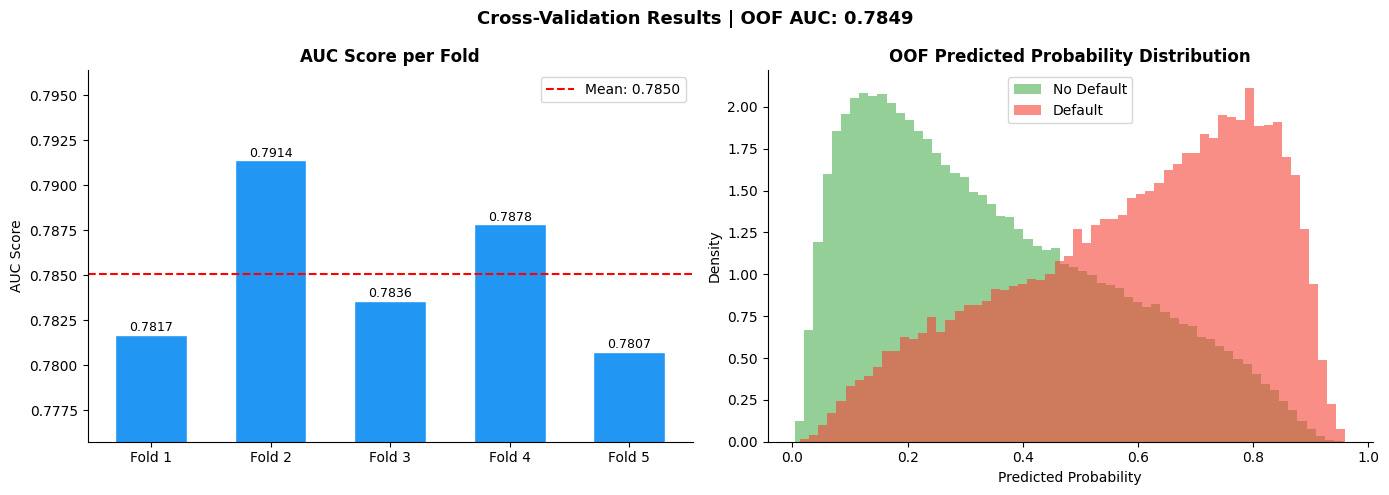

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar([f'Fold {i}' for i in range(1, N_FOLDS+1)],
                   fold_scores, color='#2196F3', edgecolor='white', width=0.6)
axes[0].axhline(np.mean(fold_scores), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {np.mean(fold_scores):.4f}')
axes[0].set_ylim(min(fold_scores) - 0.005, max(fold_scores) + 0.005)
axes[0].set_ylabel('AUC Score')
axes[0].set_title('AUC Score per Fold', fontweight='bold')
axes[0].legend()
for bar, score in zip(bars, fold_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{score:.4f}', ha='center', fontsize=9)

axes[1].hist(oof_preds[y == 0], bins=60, alpha=0.6, density=True,
             label='No Default', color='#4CAF50')
axes[1].hist(oof_preds[y == 1], bins=60, alpha=0.6, density=True,
             label='Default', color='#F44336')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('OOF Predicted Probability Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle(f'Cross-Validation Results | OOF AUC: {oof_auc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. ROC & Precision-Recall Curves

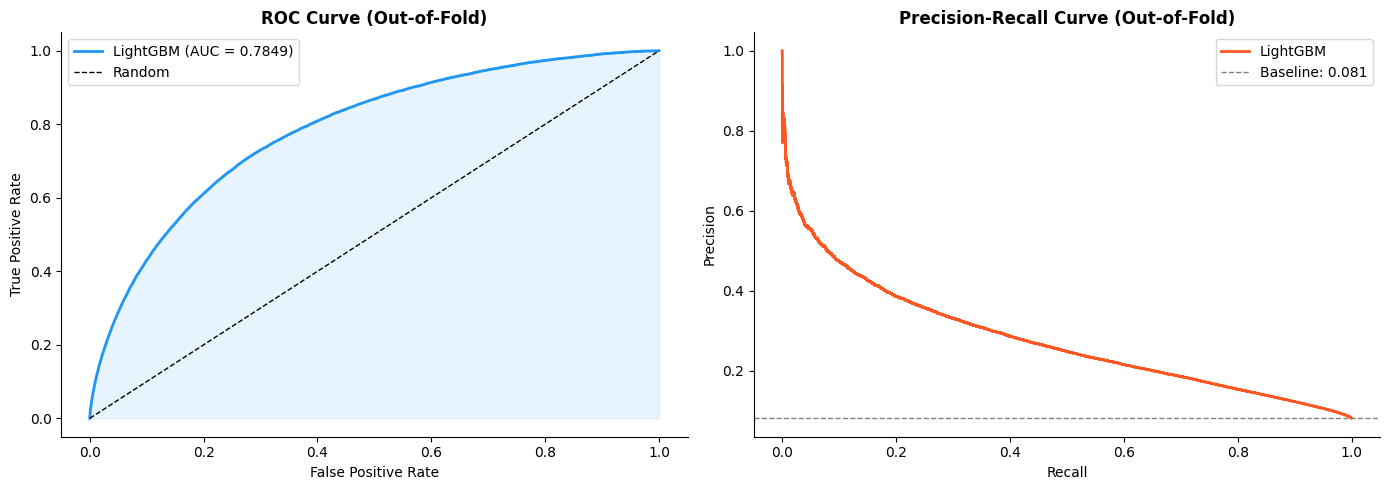

In [7]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#2196F3', linewidth=2,
             label=f'LightGBM (AUC = {oof_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Out-of-Fold)', fontweight='bold')
axes[0].legend()

precision, recall, _ = precision_recall_curve(y, oof_preds)
baseline = y.mean()
axes[1].plot(recall, precision, color='#FF5722', linewidth=2, label='LightGBM')
axes[1].axhline(baseline, color='gray', linestyle='--',
                linewidth=1, label=f'Baseline: {baseline:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Out-of-Fold)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 7. Threshold Optimization

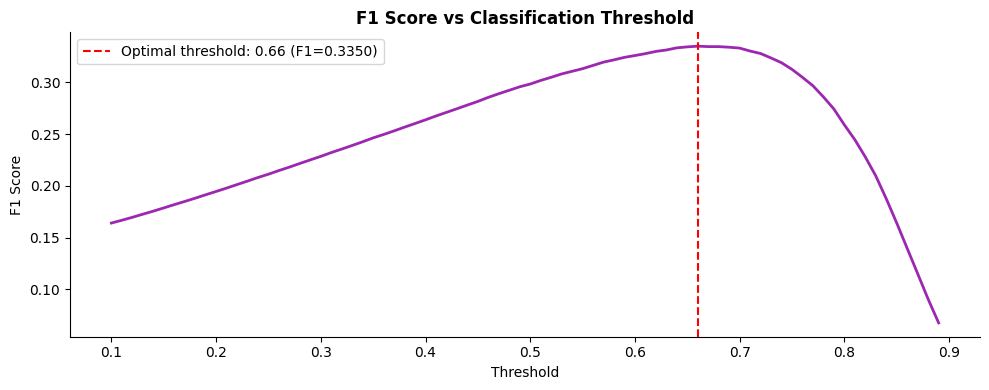

Optimal threshold : 0.66
Best F1 score     : 0.3350


In [8]:
f1_scores   = []
thres_range = np.arange(0.1, 0.9, 0.01)

for t in thres_range:
    preds_bin = (oof_preds >= t).astype(int)
    tp = ((preds_bin == 1) & (y == 1)).sum()
    fp = ((preds_bin == 1) & (y == 0)).sum()
    fn = ((preds_bin == 0) & (y == 1)).sum()
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    f1_scores.append(f1)

best_threshold = thres_range[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thres_range, f1_scores, color='#9C27B0', linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--',
           label=f'Optimal threshold: {best_threshold:.2f} (F1={best_f1:.4f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score vs Classification Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold : {best_threshold:.2f}')
print(f'Best F1 score     : {best_f1:.4f}')

---
## 8. Confusion Matrix & Classification Report

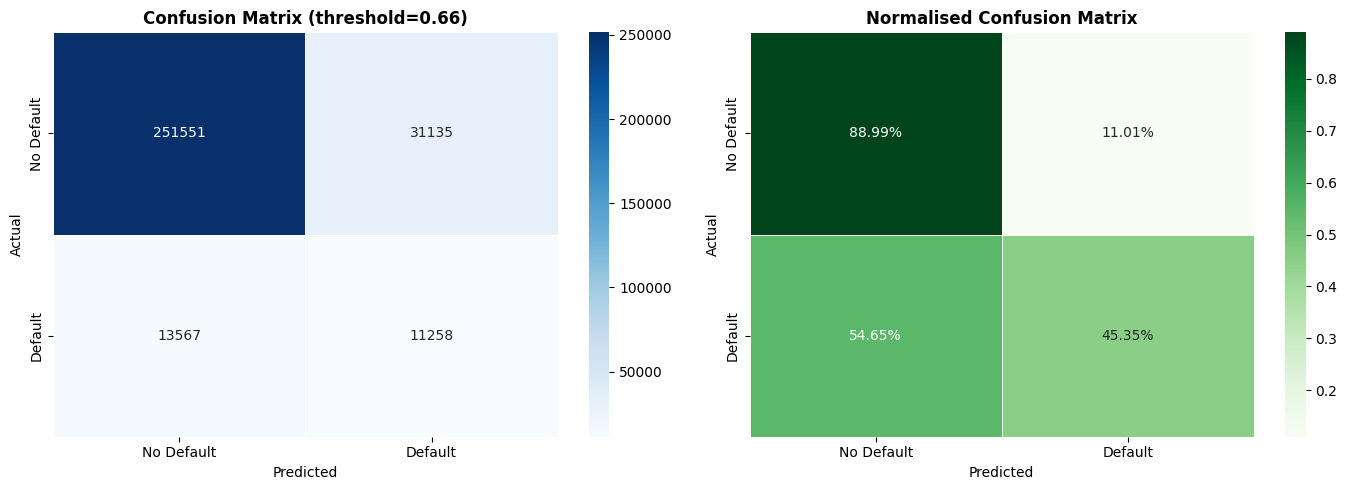


Classification Report:
              precision    recall  f1-score   support

  No Default       0.95      0.89      0.92    282686
     Default       0.27      0.45      0.33     24825

    accuracy                           0.85    307511
   macro avg       0.61      0.67      0.63    307511
weighted avg       0.89      0.85      0.87    307511



In [9]:
y_pred_binary = (oof_preds >= best_threshold).astype(int)
cm = confusion_matrix(y, y_pred_binary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=0.5)
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            linewidths=0.5)
axes[1].set_title('Normalised Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_pred_binary, target_names=['No Default', 'Default']))

---
## 9. Feature Importance

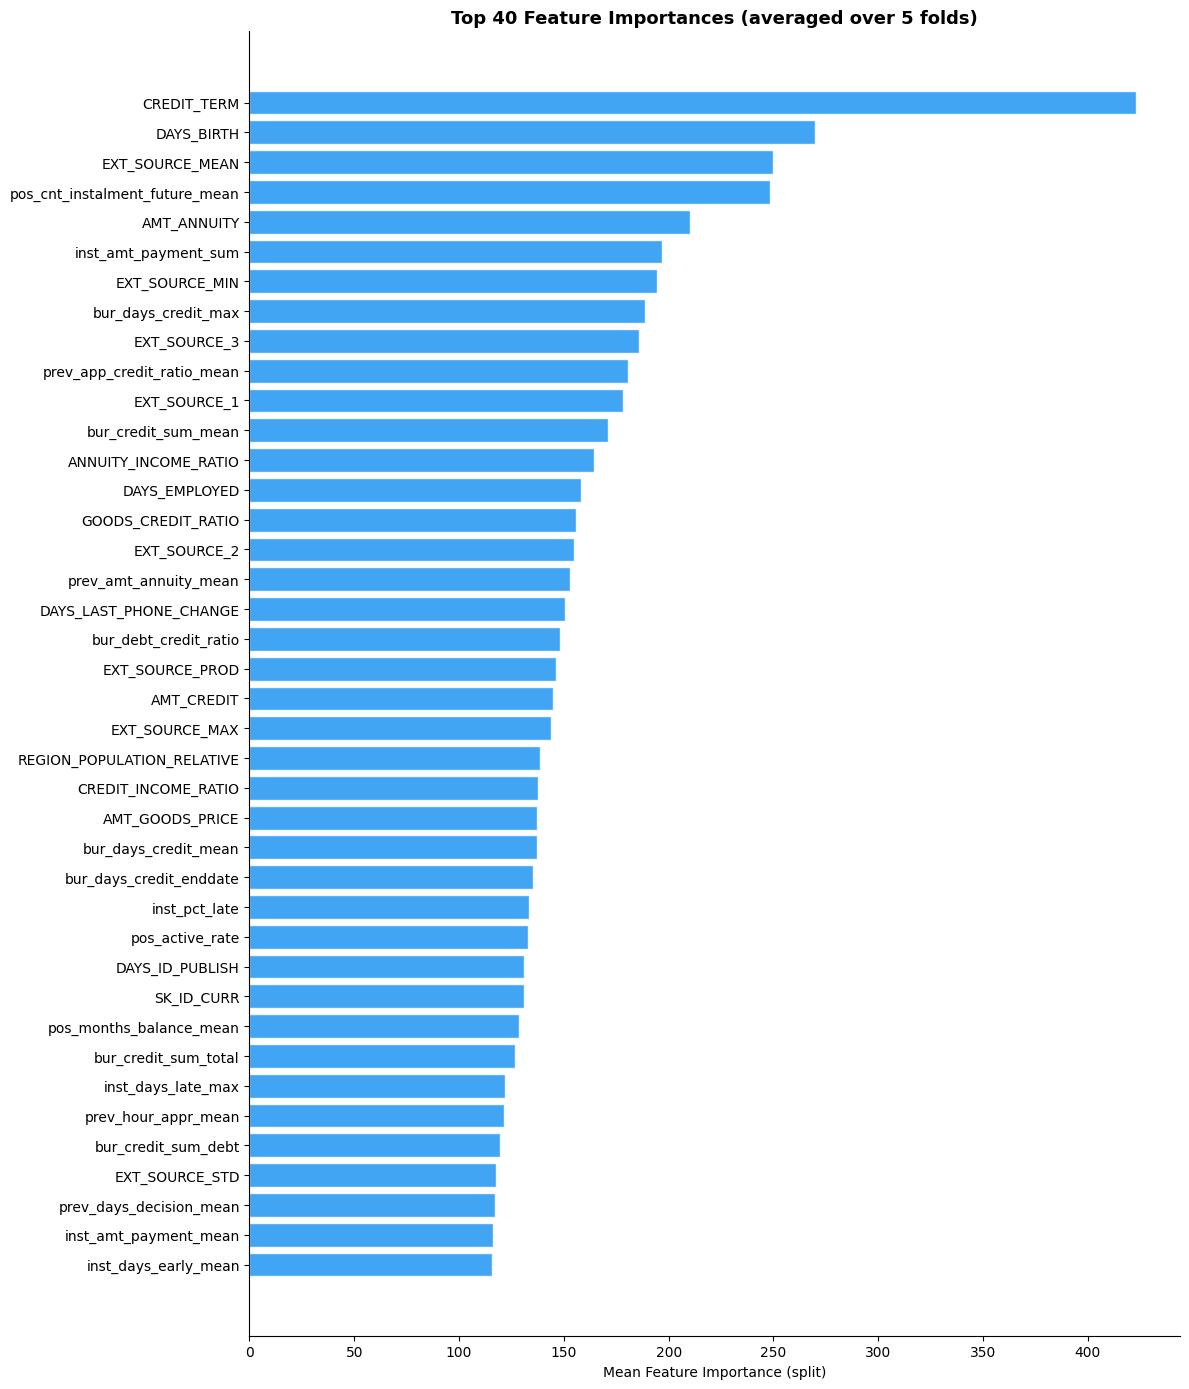


Top 20 Features:
                       feature  importance
                   CREDIT_TERM    422.8000
                    DAYS_BIRTH    270.0000
               EXT_SOURCE_MEAN    249.6000
pos_cnt_instalment_future_mean    248.4000
                   AMT_ANNUITY    210.2000
          inst_amt_payment_sum    197.0000
                EXT_SOURCE_MIN    194.4000
           bur_days_credit_max    188.8000
                  EXT_SOURCE_3    185.8000
    prev_app_credit_ratio_mean    180.4000
                  EXT_SOURCE_1    178.0000
           bur_credit_sum_mean    171.0000
          ANNUITY_INCOME_RATIO    164.2000
                 DAYS_EMPLOYED    158.4000
            GOODS_CREDIT_RATIO    156.0000
                  EXT_SOURCE_2    154.8000
         prev_amt_annuity_mean    152.8000
        DAYS_LAST_PHONE_CHANGE    150.4000
         bur_debt_credit_ratio    148.0000
               EXT_SOURCE_PROD    146.2000


In [10]:
mean_imp = (
    feature_imps.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_n     = 40
top_feats = mean_imp.head(top_n)

fig, ax = plt.subplots(figsize=(12, 14))
ax.barh(top_feats['feature'][::-1], top_feats['importance'][::-1],
        color='#2196F3', edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean Feature Importance (split)')
ax.set_title(f'Top {top_n} Feature Importances (averaged over {N_FOLDS} folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 20 Features:')
print(mean_imp.head(20).to_string(index=False))

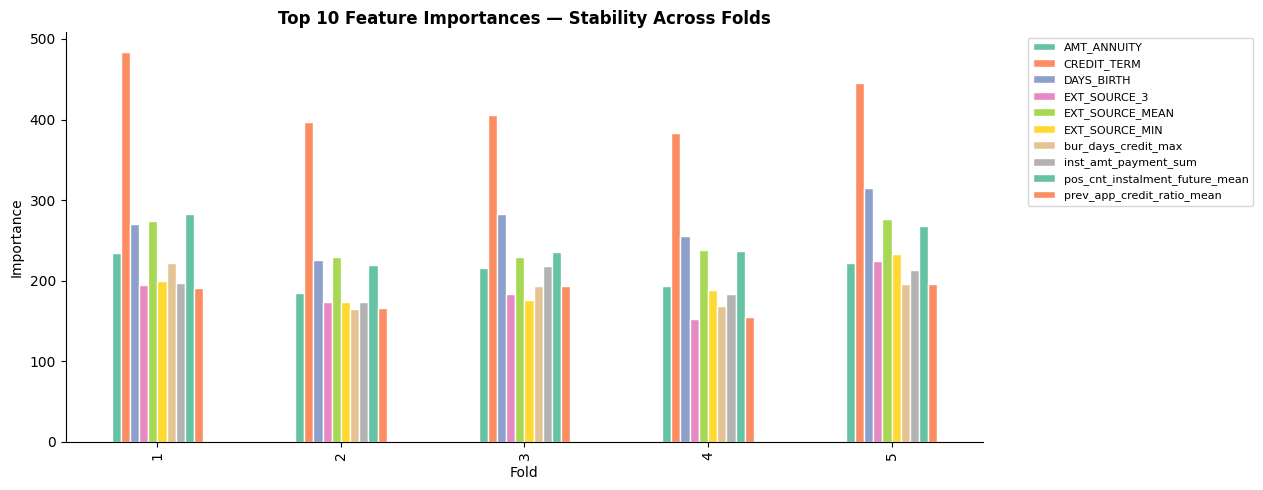

In [11]:
# Stability of top 10 features across folds
top10_feats     = mean_imp.head(10)['feature'].tolist()
fold_imp_pivot  = feature_imps[feature_imps['feature'].isin(top10_feats)].pivot(
    index='fold', columns='feature', values='importance'
)

fig, ax = plt.subplots(figsize=(13, 5))
fold_imp_pivot.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Top 10 Feature Importances — Stability Across Folds', fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('Importance')
ax.legend(loc='upper right', fontsize=8, bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

---
## 10. Low-Importance Feature Pruning

In [12]:
zero_imp = mean_imp[mean_imp['importance'] == 0]['feature'].tolist()
print(f'Features with zero importance: {len(zero_imp)}')

DROP_LOW_IMPORTANCE = True

if DROP_LOW_IMPORTANCE and len(zero_imp) > 0:
    print(f'Dropping {len(zero_imp)} zero-importance features')
    X_pruned      = X.drop(columns=zero_imp, errors='ignore')
    X_test_pruned = X_test.drop(columns=zero_imp, errors='ignore')
else:
    X_pruned      = X.copy()
    X_test_pruned = X_test.copy()

print(f'Pruned X shape     : {X_pruned.shape}')
print(f'Pruned X_test shape: {X_test_pruned.shape}')

Features with zero importance: 17
Dropping 17 zero-importance features
Pruned X shape     : (307511, 256)
Pruned X_test shape: (48744, 256)


---
## 11. Final Model — CV with Pruned Features

In [13]:
skf_final    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof_final    = np.zeros(len(X_pruned))
test_final   = np.zeros(len(X_test_pruned))
final_scores = []
final_models = []
final_imp    = pd.DataFrame()

print(f'Final model — {N_FOLDS}-fold CV on {X_pruned.shape[1]} features')
print('=' * 55)

for fold, (tr_idx, val_idx) in enumerate(skf_final.split(X_pruned, y), 1):
    X_tr, X_val = X_pruned.iloc[tr_idx], X_pruned.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx],        y.iloc[val_idx]

    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    val_pred = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)

    oof_final[val_idx]  = val_pred
    test_final         += model.predict_proba(X_test_pruned)[:, 1] / N_FOLDS
    final_scores.append(fold_auc)
    final_models.append(model)

    fi = pd.DataFrame({'feature': X_pruned.columns,
                       'importance': model.feature_importances_, 'fold': fold})
    final_imp = pd.concat([final_imp, fi], ignore_index=True)

    print(f'Fold {fold} | Best iter: {model.best_iteration_:>4} | AUC: {fold_auc:.5f}')

print('=' * 55)
final_oof_auc = roc_auc_score(y, oof_final)
print(f'\nFold AUC scores : {[round(s,5) for s in final_scores]}')
print(f'Mean CV AUC     : {np.mean(final_scores):.5f} ± {np.std(final_scores):.5f}')
print(f'OOF AUC         : {final_oof_auc:.5f}')

Final model — 5-fold CV on 256 features
[200]	valid_0's auc: 0.780796
[400]	valid_0's auc: 0.782104
Fold 1 | Best iter:  377 | AUC: 0.78240
[200]	valid_0's auc: 0.788752
[400]	valid_0's auc: 0.790627
Fold 2 | Best iter:  480 | AUC: 0.79083
[200]	valid_0's auc: 0.780888
[400]	valid_0's auc: 0.783116
Fold 3 | Best iter:  381 | AUC: 0.78318
[200]	valid_0's auc: 0.784974
[400]	valid_0's auc: 0.787421
[600]	valid_0's auc: 0.787313
Fold 4 | Best iter:  515 | AUC: 0.78761
[200]	valid_0's auc: 0.779136
[400]	valid_0's auc: 0.781847
Fold 5 | Best iter:  432 | AUC: 0.78207

Fold AUC scores : [0.7824, 0.79083, 0.78318, 0.78761, 0.78207]
Mean CV AUC     : 0.78522 ± 0.00344
OOF AUC         : 0.78519


---
## 12. Model Calibration

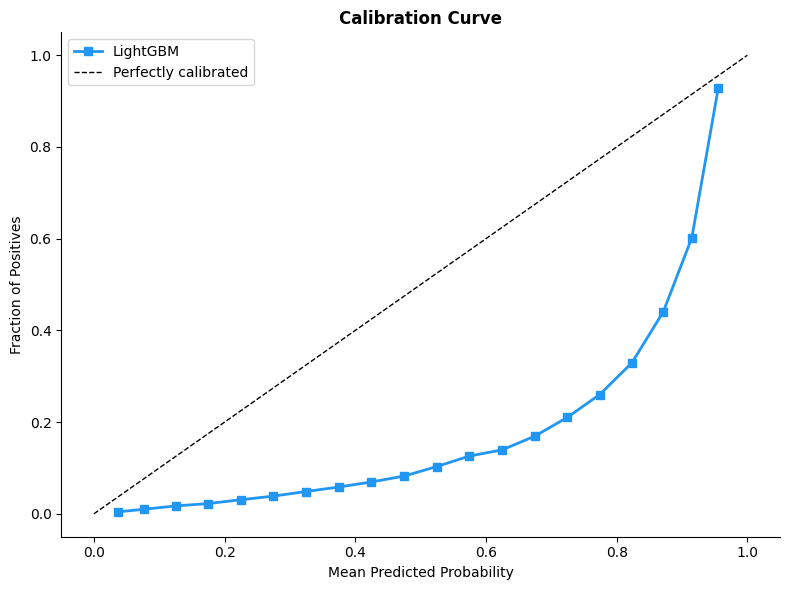

In [14]:
fraction_of_positives, mean_predicted_value = calibration_curve(
    y, oof_final, n_bins=20
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_predicted_value, fraction_of_positives,
        's-', color='#2196F3', linewidth=2, label='LightGBM')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 13. Decile Analysis

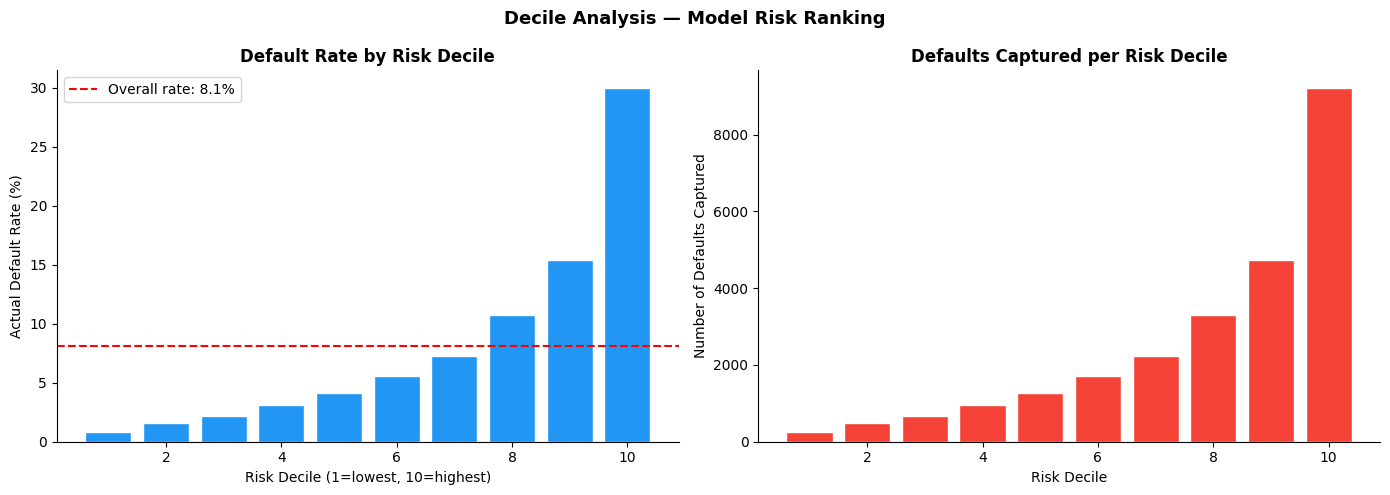


Decile Summary:


,decile,count,defaults,default_rate,avg_prob
0,1,30752,251,0.0082,0.0630
1,2,30751,496,0.0161,0.1197
2,3,30751,675,0.0220,0.1715
3,4,30751,954,0.0310,0.2265
4,5,30751,1257,0.0409,0.2879
5,6,30751,1708,0.0555,0.3582
6,7,30751,2244,0.0730,0.4400
7,8,30751,3294,0.1071,0.5346
8,9,30751,4729,0.1538,0.6456
9,10,30751,9217,0.2997,0.7905


In [15]:
pred_df = pd.DataFrame({'y_true': y.values, 'y_prob': oof_final})
pred_df['decile'] = pd.qcut(pred_df['y_prob'], q=10, labels=False, duplicates='drop') + 1

decile_stats = pred_df.groupby('decile').agg(
    count        = ('y_true', 'count'),
    defaults     = ('y_true', 'sum'),
    default_rate = ('y_true', 'mean'),
    avg_prob     = ('y_prob', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(decile_stats['decile'], decile_stats['default_rate'] * 100,
            color='#2196F3', edgecolor='white')
axes[0].axhline(y.mean() * 100, color='red', linestyle='--',
                label=f'Overall rate: {y.mean()*100:.1f}%')
axes[0].set_xlabel('Risk Decile (1=lowest, 10=highest)')
axes[0].set_ylabel('Actual Default Rate (%)')
axes[0].set_title('Default Rate by Risk Decile', fontweight='bold')
axes[0].legend()

axes[1].bar(decile_stats['decile'], decile_stats['defaults'],
            color='#F44336', edgecolor='white')
axes[1].set_xlabel('Risk Decile')
axes[1].set_ylabel('Number of Defaults Captured')
axes[1].set_title('Defaults Captured per Risk Decile', fontweight='bold')

plt.suptitle('Decile Analysis — Model Risk Ranking', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nDecile Summary:')
display(decile_stats)

---
## 14. Save OOF Predictions & Submission File

In [16]:
# OOF predictions (useful for stacking later)
oof_df = pd.DataFrame({
    'SK_ID_CURR': train['SK_ID_CURR'].values,
    'TARGET'    : y.values,
    'OOF_PRED'  : oof_final
})
oof_out = os.path.join(DATA_PATH, 'oof_predictions_lgbm.csv')
oof_df.to_csv(oof_out, index=False)
print(f'✅ OOF predictions saved → {oof_out}')

# Submission file
submission = pd.DataFrame({
    'SK_ID_CURR': test['SK_ID_CURR'].values,
    'TARGET'    : test_final
})
sub_out = os.path.join(DATA_PATH, 'submission_lgbm.csv')
submission.to_csv(sub_out, index=False)
print(f'✅ Submission file saved  → {sub_out}')

print(f'\nSubmission shape     : {submission.shape}')
print(f'Predicted prob range : [{test_final.min():.4f}, {test_final.max():.4f}]')
print(f'Predicted prob mean  : {test_final.mean():.4f}')
submission.head()

✅ OOF predictions saved → /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk/oof_predictions_lgbm.csv
✅ Submission file saved  → /Users/salmaahmed/.cache/kagglehub/competitions/home-credit-default-risk/submission_lgbm.csv

Submission shape     : (48744, 2)
Predicted prob range : [0.0100, 0.9455]
Predicted prob mean  : 0.3532


,SK_ID_CURR,TARGET
0,100001,0.2505
1,100005,0.7099
2,100013,0.1424
3,100028,0.2455
4,100038,0.6094


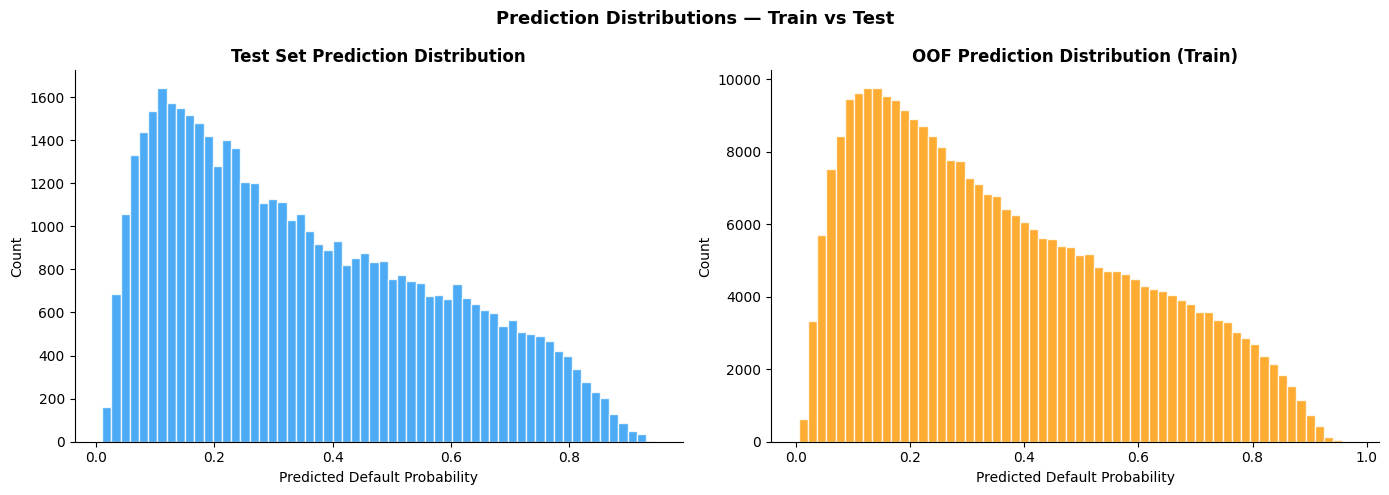

Similar distributions confirm no train/test distribution shift.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_final, bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Predicted Default Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Prediction Distribution', fontweight='bold')

axes[1].hist(oof_final, bins=60, color='#FF9800', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Predicted Default Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('OOF Prediction Distribution (Train)', fontweight='bold')

plt.suptitle('Prediction Distributions — Train vs Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Similar distributions confirm no train/test distribution shift.')

---
## 15. Results Summary

In [18]:
print('=' * 55)
print('         FINAL MODEL RESULTS SUMMARY')
print('=' * 55)
print(f'Model             : LightGBM (GBDT)')
print(f'Features used     : {X_pruned.shape[1]}')
print(f'CV strategy       : {N_FOLDS}-fold Stratified K-Fold')
print(f'Mean CV AUC       : {np.mean(final_scores):.5f} ± {np.std(final_scores):.5f}')
print(f'OOF AUC           : {final_oof_auc:.5f}')
print(f'Optimal threshold : {best_threshold:.2f}')
print(f'Submission rows   : {len(submission):,}')
print('=' * 55)

final_mean_imp = final_imp.groupby('feature')['importance'].mean().sort_values(ascending=False)
print('\nTop 10 Most Important Features:')
print(final_mean_imp.head(10).to_string())

print('\nNext steps:')
print('  1. Hyperparameter tuning with Optuna')
print('  2. Try XGBoost / CatBoost for ensemble')
print('  3. Add more feature interactions')
print('  4. Stacking with OOF predictions')

         FINAL MODEL RESULTS SUMMARY
Model             : LightGBM (GBDT)
Features used     : 256
CV strategy       : 5-fold Stratified K-Fold
Mean CV AUC       : 0.78522 ± 0.00344
OOF AUC           : 0.78519
Optimal threshold : 0.66
Submission rows   : 48,744

Top 10 Most Important Features:
feature
CREDIT_TERM                      439.2000
DAYS_BIRTH                       268.6000
EXT_SOURCE_MEAN                  262.0000
pos_cnt_instalment_future_mean   254.2000
AMT_ANNUITY                      230.2000
prev_app_credit_ratio_mean       199.4000
EXT_SOURCE_MIN                   197.0000
inst_amt_payment_sum             193.0000
EXT_SOURCE_3                     188.6000
EXT_SOURCE_1                     187.8000

Next steps:
  1. Hyperparameter tuning with Optuna
  2. Try XGBoost / CatBoost for ensemble
  3. Add more feature interactions
  4. Stacking with OOF predictions
